# Clasp Queens: adaptive-policy and fixed-depth incumbent analytics

This notebook compares the six adaptive RF-depth policies in `02_policies` with fixed RF depths 5, 10, 15, 20, and 30 from `01_initial_cq`. Lower PAR10 is better. Every displayed incumbent configuration is independently evaluated on all 484 training instances at fixed target quantile seed 0.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

HERE = Path.cwd().resolve()
if not (HERE / 'results').is_dir():
    HERE = (Path.cwd() / 'experiments/aclib/clasp_queens_surrogate/02_policies').resolve()
ACLIB_ROOT = HERE.parents[1]
if str(ACLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(ACLIB_ROOT))

from policy_analytics import (
    build_policy_comparison,
    plot_common_horizon_incumbents,
    plot_incumbent_trajectories,
    plot_observed_endpoint_incumbents,
)

BENCHMARK_KEY = 'clasp_queens'
INITIAL_DIRECTORY = HERE.parent / '01_initial_cq'
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': False})
print('Policy experiment:', HERE)
print('Fixed-depth experiment:', INITIAL_DIRECTORY)

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/pyt

Policy experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/02_policies
Fixed-depth experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/01_initial_cq


## Data loading, validation, and interruption coverage

Table: persistence status and observed trial count for every adaptive policy and SMAC seed. The cluster-wide `SIGBUS` interruption left some `runhistory.json` or `intensifier.json` files zero-filled/truncated. Exact trajectories are shown only when both artifacts are readable. The fixed-depth runs are complete at 5,000 trials. Adaptive runs are partial, and their lines stop at the last safely persisted trial.

In [2]:
comparison = build_policy_comparison(
    HERE,
    BENCHMARK_KEY,
    INITIAL_DIRECTORY,
)
display(
    comparison.availability.pivot(
        index='policy', columns='smac_seed', values='trajectory_status'
    )
)
display(
    comparison.availability.pivot(
        index='policy', columns='smac_seed', values='observed_trials'
    )
)
print('Full-training validation cache:', comparison.validation_cache_file)

Validation cache hit: 39 configurations from /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/02_policies/analytics_cache/full_training_validation_qseed_0.json.


smac_seed,0,1,2
policy,,,
Error/variance trend,trajectory unavailable,recoverable partial run,recoverable partial run
Oracle depth schedule,recoverable partial run,recoverable partial run,recoverable partial run
Rotating saturation k=50,trajectory unavailable,recoverable partial run,recoverable partial run
Saturation k=100,recoverable partial run,trajectory unavailable,trajectory unavailable
Saturation k=250,recoverable partial run,recoverable partial run,recoverable partial run
Saturation k=50,recoverable partial run,trajectory unavailable,recoverable partial run


smac_seed,0,1,2
policy,,,
Error/variance trend,3178,2150,2327
Oracle depth schedule,3414,2327,4250
Rotating saturation k=50,3770,3667,2974
Saturation k=100,3005,2630,3379
Saturation k=250,2977,2677,3489
Saturation k=50,2314,3365,4277


Full-training validation cache: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/02_policies/analytics_cache/full_training_validation_qseed_0.json


## Incumbent value versus SMAC trial

Step plots: one figure per SMAC seed comparing adaptive policies (solid colored lines) with fixed depths (dashed gray lines). Each height is the current SMAC incumbent re-evaluated on every training instance at quantile seed 0. An `×` marks a partial adaptive run's last persisted point. The second set repeats the comparison on a logarithmic PAR10 axis.

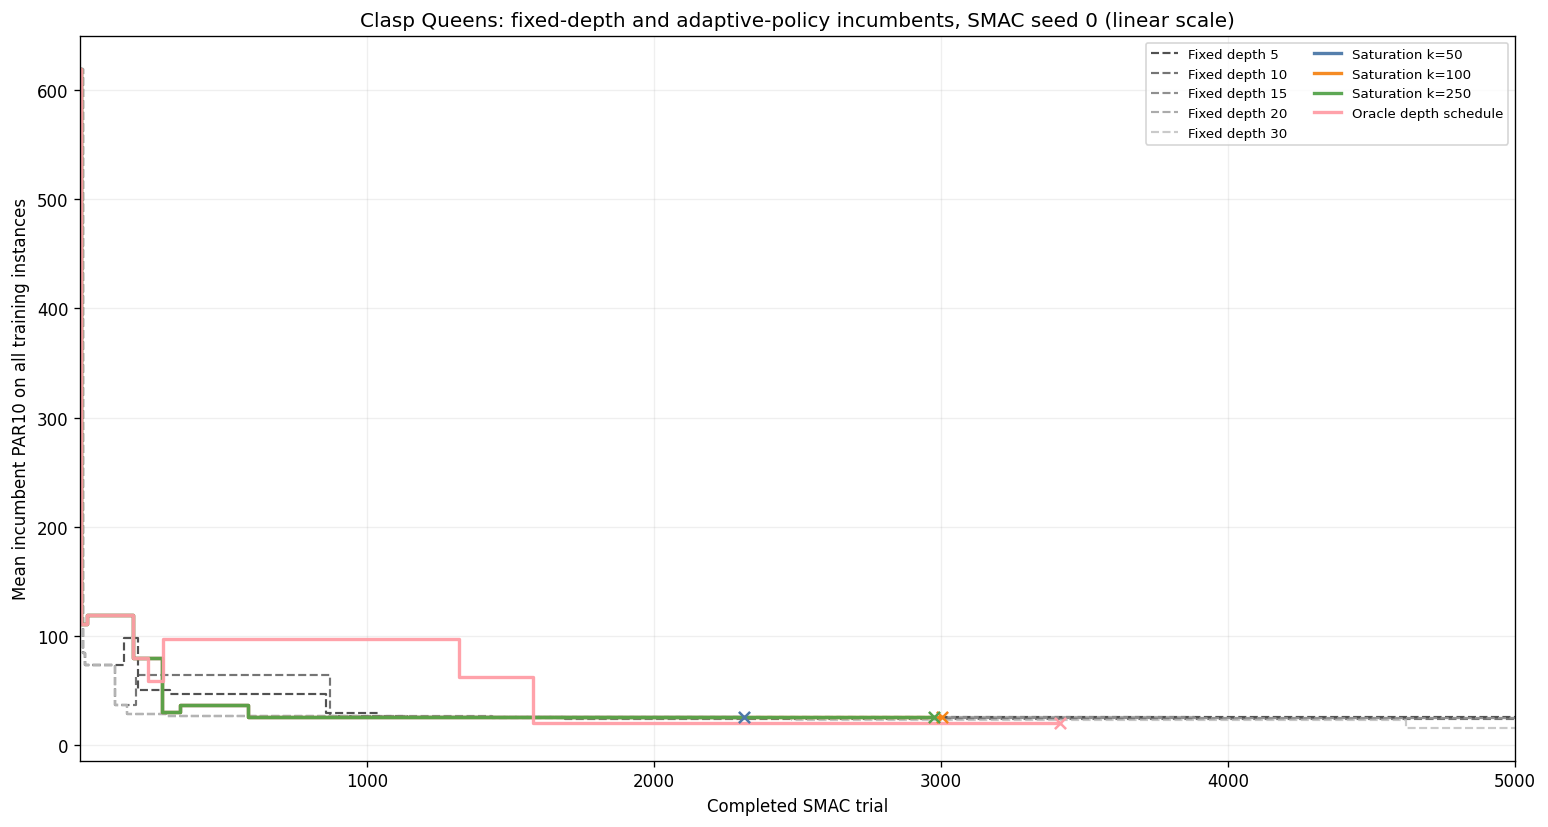

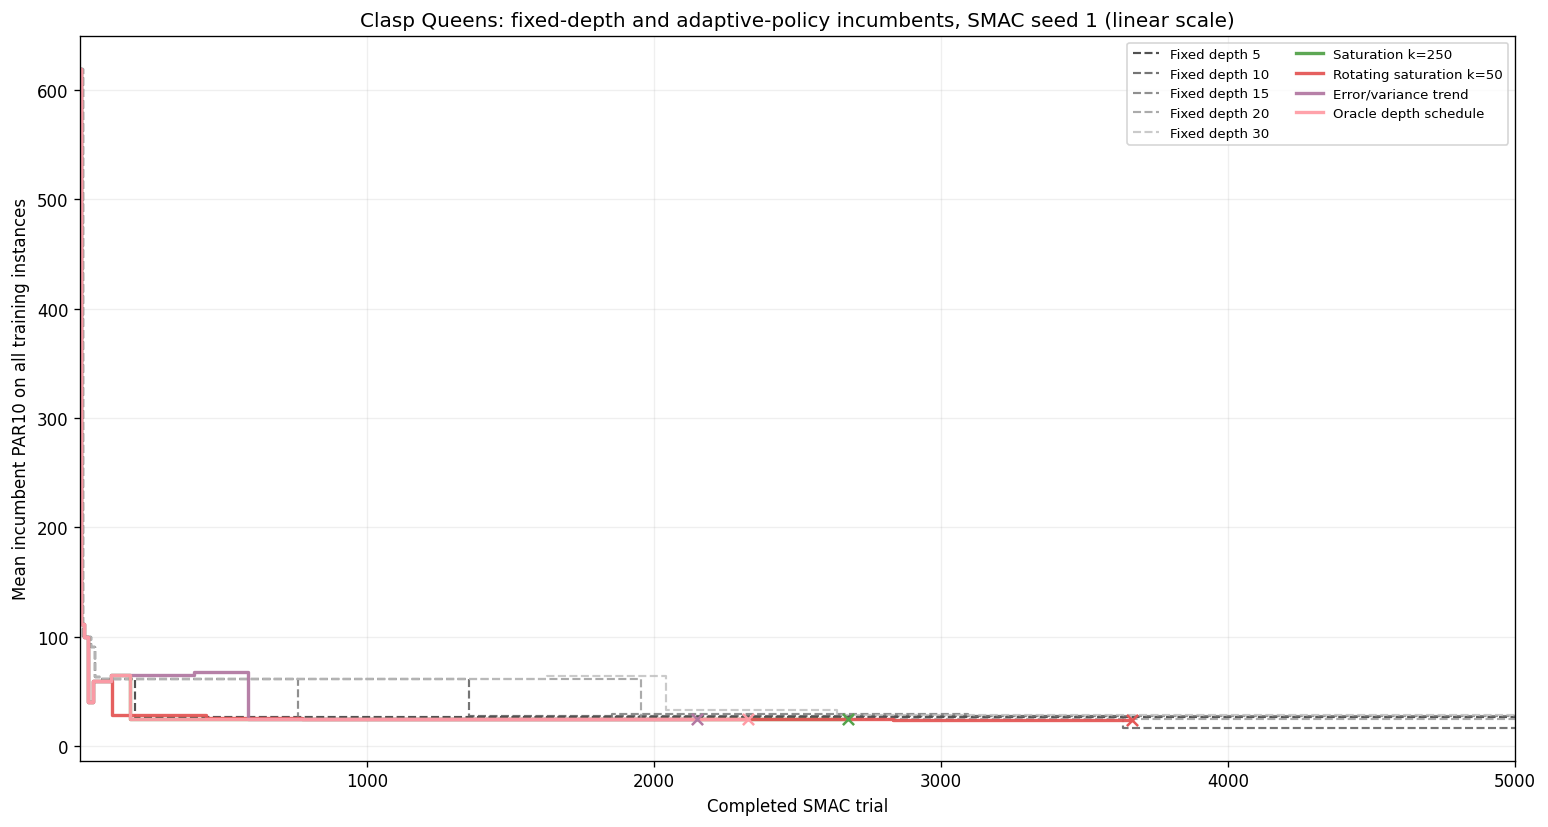

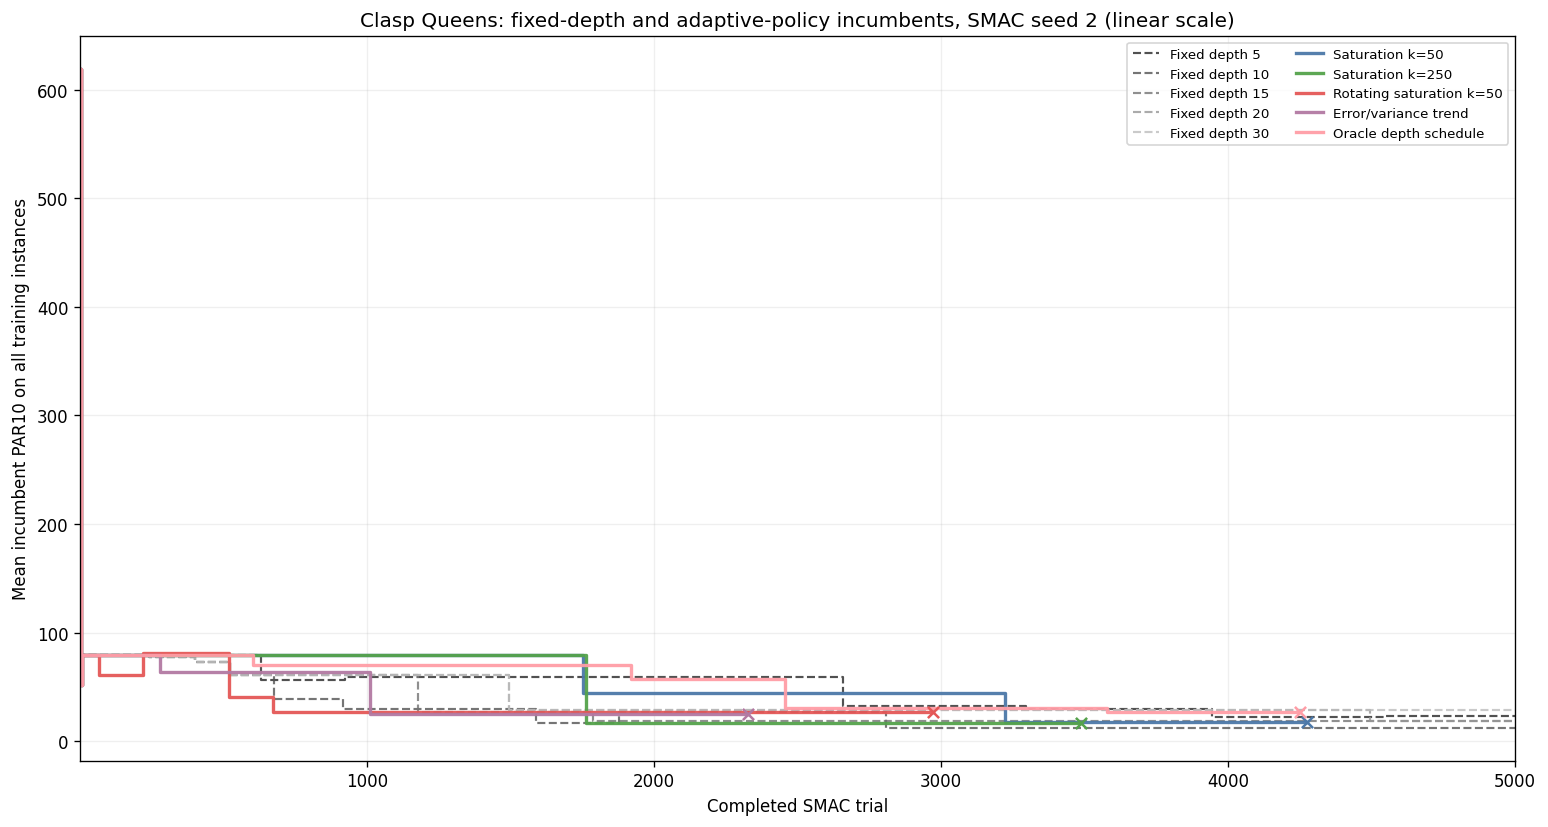

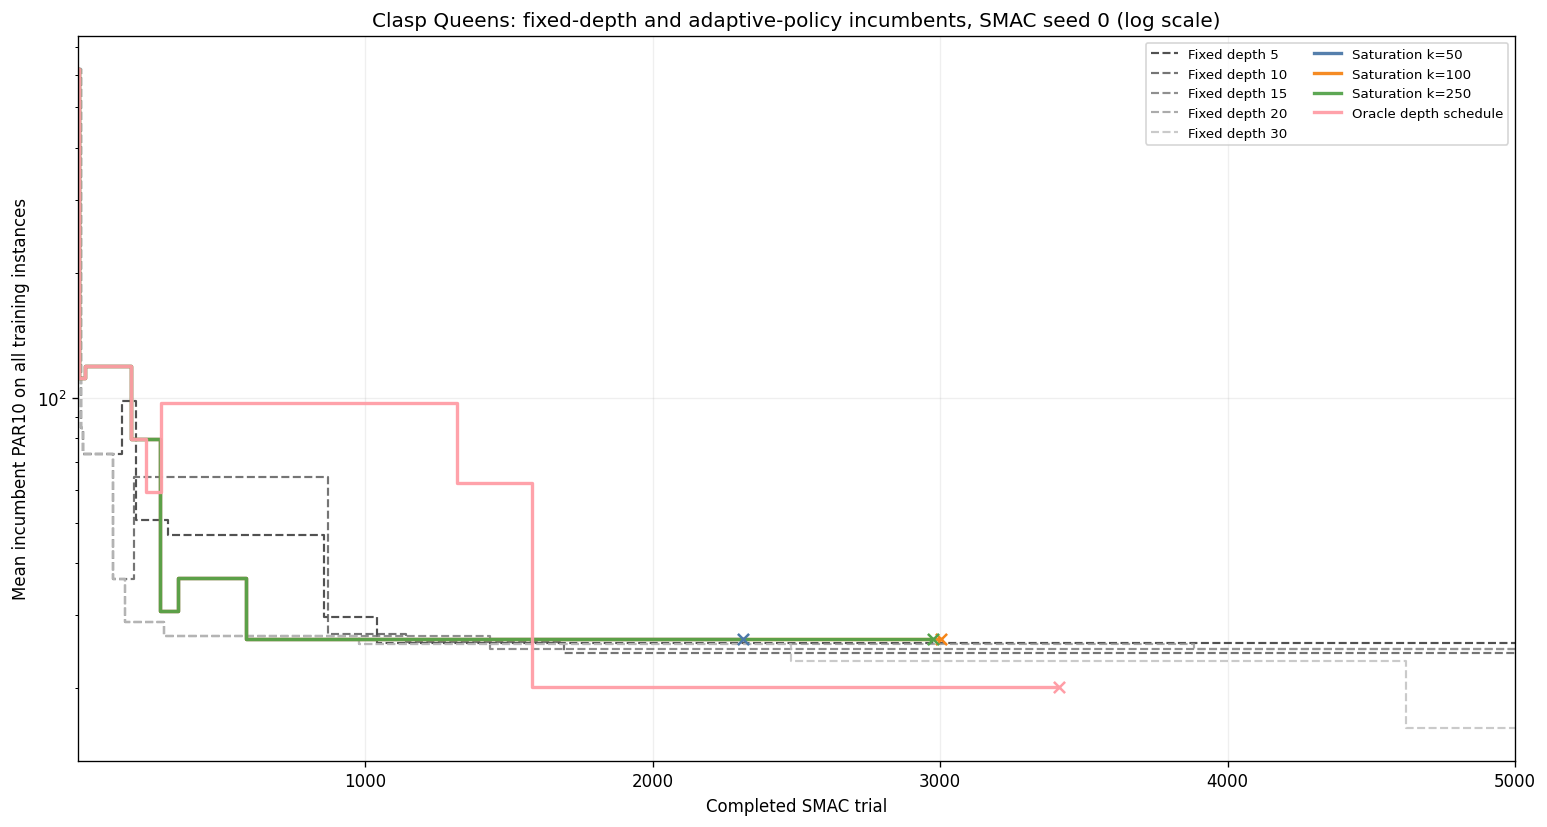

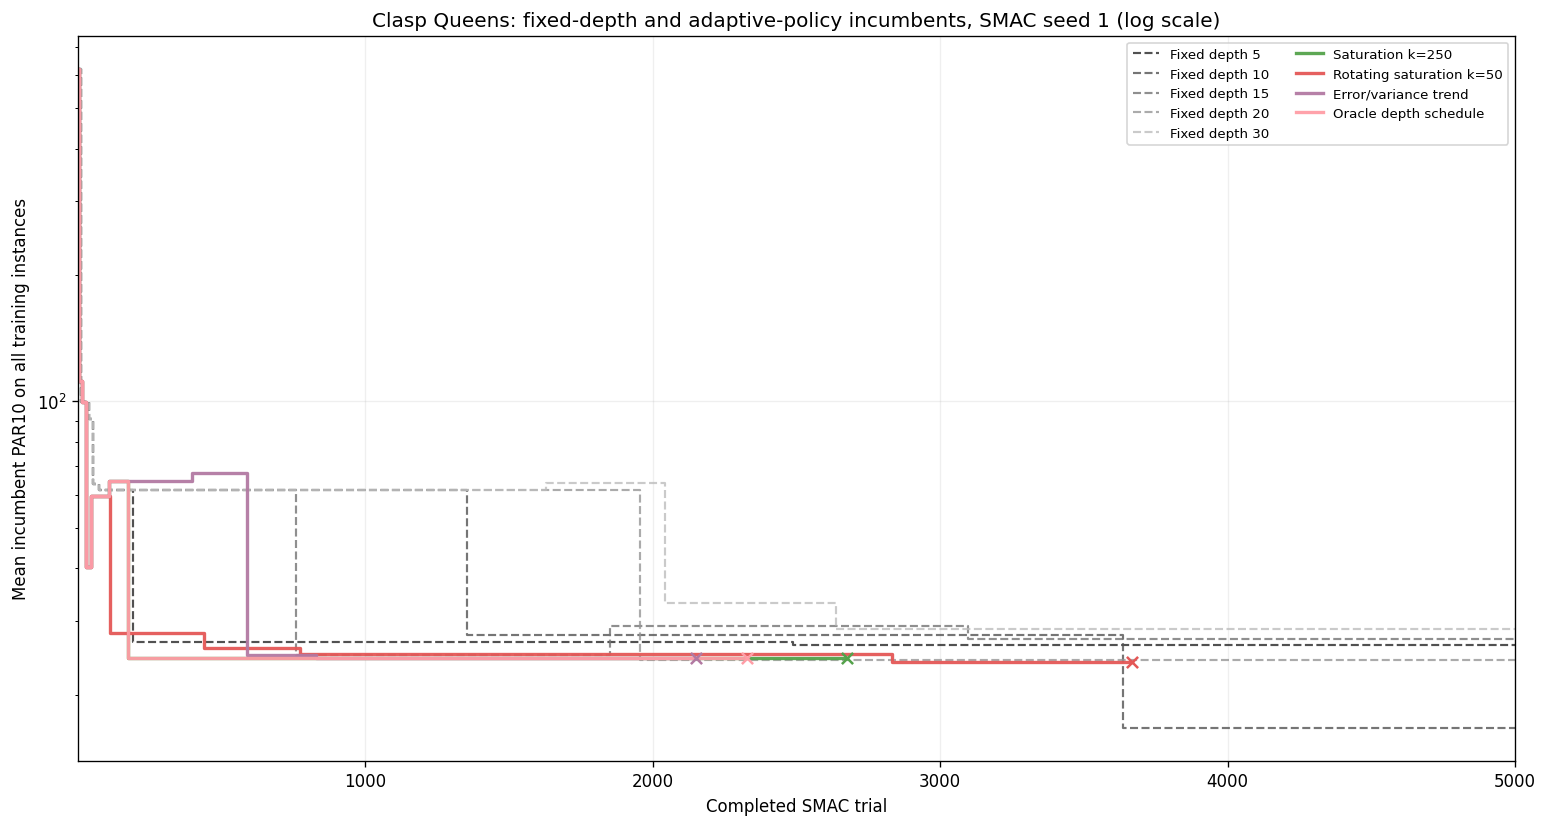

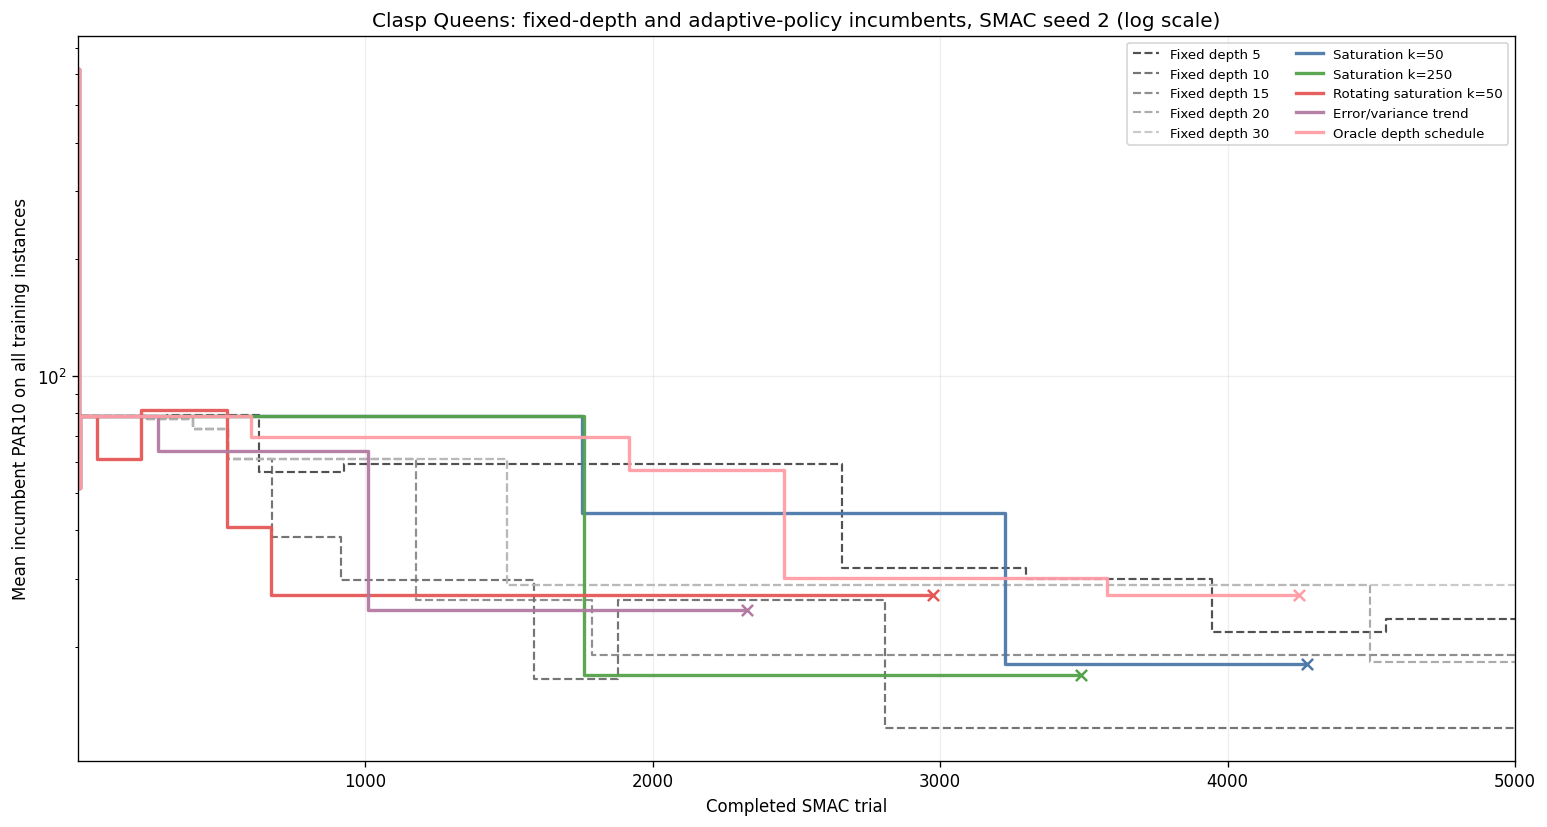

In [3]:
plot_incumbent_trajectories(comparison)
plt.show()

plot_incumbent_trajectories(comparison, logarithmic=True)
plt.show()

## Final observed incumbent by SMAC seed and policy

Horizontal bar charts: independently validated incumbent PAR10 at each run's last persisted trial. Fixed-depth values are true 5,000-trial finals; adaptive-policy values are interrupted endpoints at different trial counts and must not be interpreted as 5,000-trial finals. The table includes each endpoint trial explicitly.

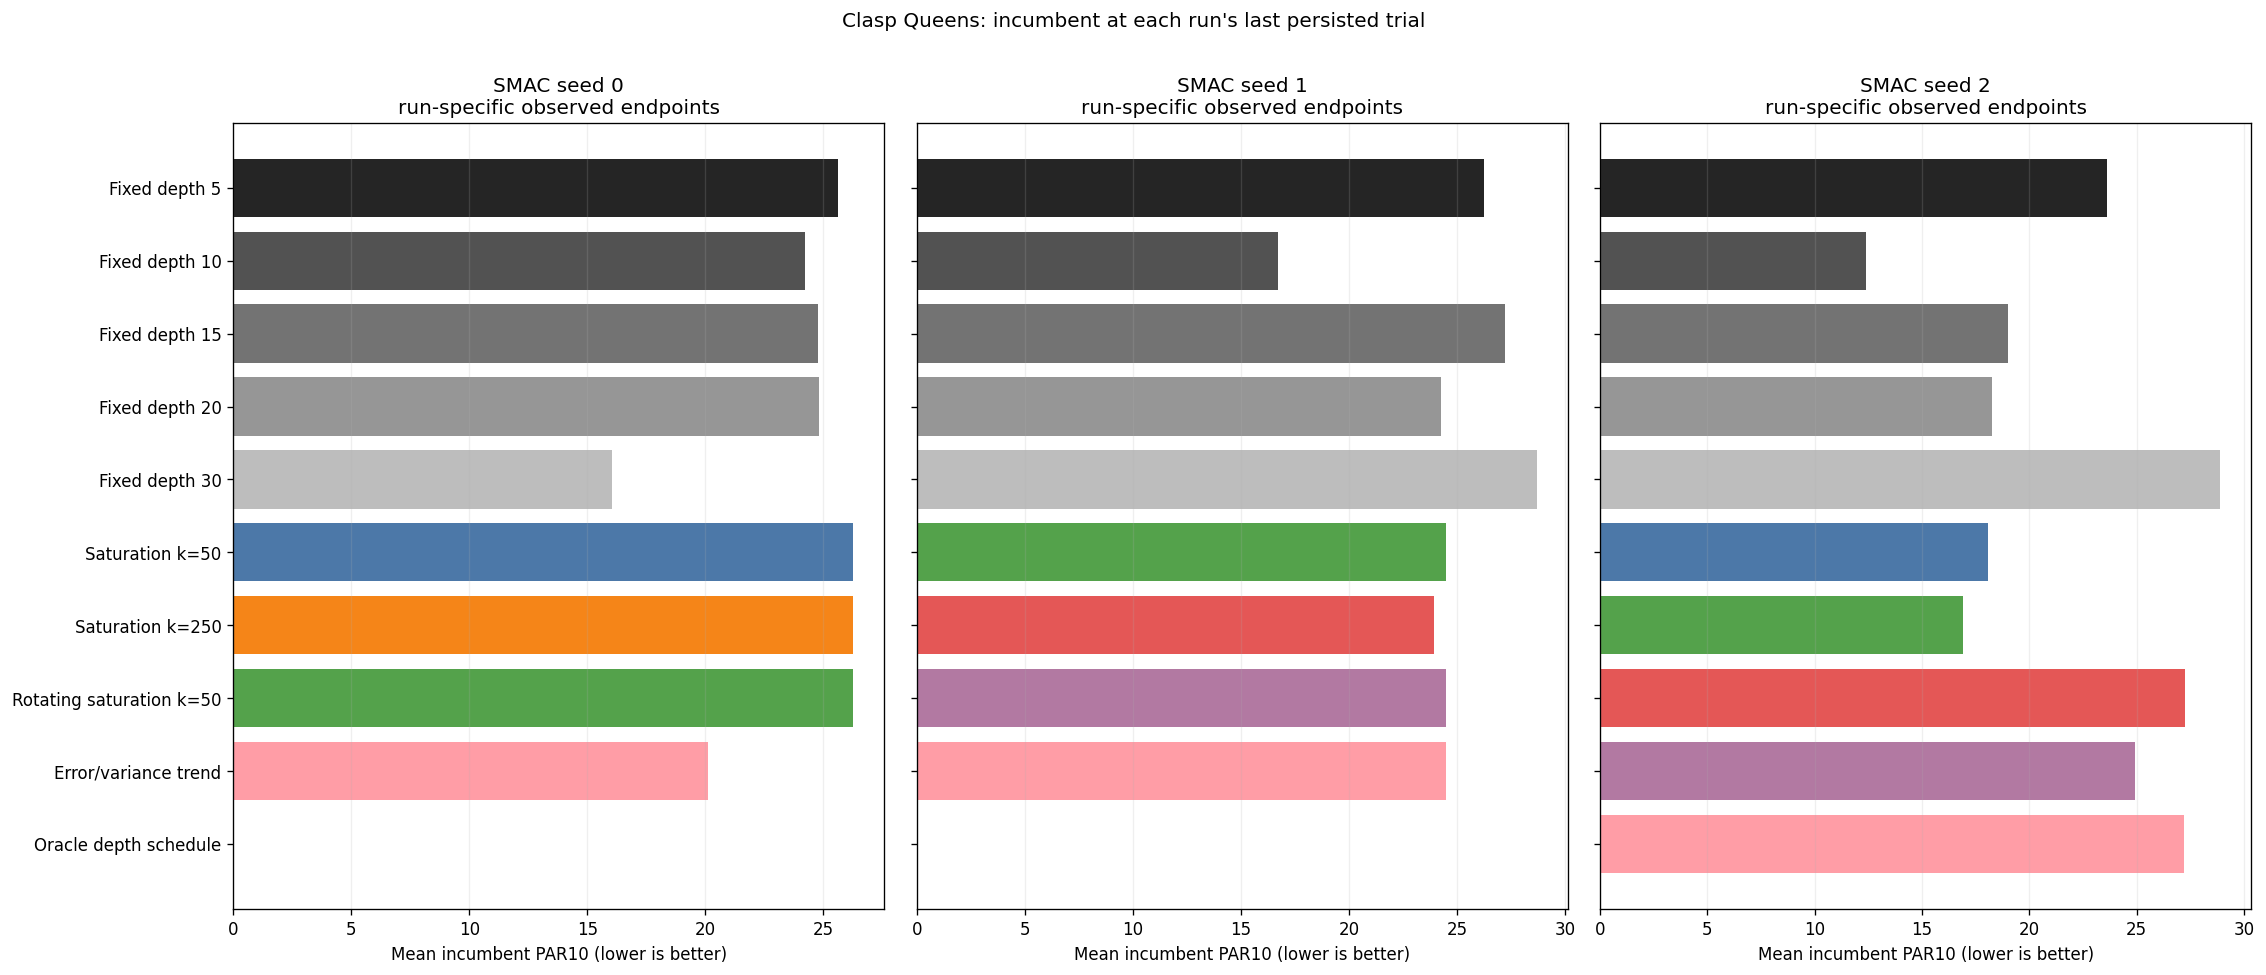

family  trial  \
smac_seed method                                             
0         Fixed depth 5                 fixed depth   5000   
          Fixed depth 10                fixed depth   5000   
          Fixed depth 15                fixed depth   5000   
          Fixed depth 20                fixed depth   5000   
          Fixed depth 30                fixed depth   5000   
          Saturation k=50           adaptive policy   2314   
          Saturation k=100          adaptive policy   3005   
          Saturation k=250          adaptive policy   2977   
          Oracle depth schedule     adaptive policy   3414   
1         Fixed depth 5                 fixed depth   5000   
          Fixed depth 10                fixed depth   5000   
          Fixed depth 15                fixed depth   5000   
          Fixed depth 20                fixed depth   5000   
          Fixed depth 30                fixed depth   5000   
          Saturation k=250          adaptive policy   2677   
          Rotating saturation k=50  adaptive policy   3667   
          Error/variance trend      adaptive policy   2150   
          Oracle depth schedule     adaptive policy   2327   
2         Fixed depth 5                 fixed depth   5000   
          Fixed depth 10                fixed depth   5000   
          Fixed depth 15                fixed depth   5000   
          Fixed depth 20                fixed depth   5000   
          Fixed depth 30                fixed depth   5000   
          Saturation k=50           adaptive policy   4277   
          Saturation k=250          adaptive policy   3489   
          Rotating saturation k=50  adaptive policy   2974   
          Error/variance trend      adaptive policy   2327   
          Oracle depth schedule     adaptive policy   4250   

                                    full_training_par10  config_id  \
smac_seed method                                                     
0         Fixed depth 5                       25.601854        173   
          Fixed depth 10                      24.230729        300   
          Fixed depth 15                      24.790754        308   
          Fixed depth 20                      24.808152        828   
          Fixed depth 30                      16.041059        992   
          Saturation k=50                     26.263510        115   
          Saturation k=100                    26.263510        115   
          Saturation k=250                    26.263510        115   
          Oracle depth schedule               20.107653        250   
1         Fixed depth 5                       26.243285        545   
          Fixed depth 10                      16.701370        605   
          Fixed depth 15                      27.189507        480   
          Fixed depth 20                      24.231310        421   
          Fixed depth 30                      28.679822        443   
          Saturation k=250                    24.477254         39   
          Rotating saturation k=50            23.937784        766   
          Error/variance trend                24.458876        133   
          Oracle depth schedule               24.477254         39   
2         Fixed depth 5                       23.623321        537   
          Fixed depth 10                      12.369495        402   
          Fixed depth 15                      19.010385        347   
          Fixed depth 20                      18.259514        695   
          Fixed depth 30                      28.896640        297   
          Saturation k=50                     18.076906        777   
          Saturation k=250                    16.900913        430   
          Rotating saturation k=50            27.238637        127   
          Error/variance trend                24.939557        250   
          Oracle depth schedule               27.225021        655   

                                    run_complete  
smac_seed method                

In [4]:
plot_observed_endpoint_incumbents(comparison)
plt.show()

endpoint_table = comparison.endpoints[[
    'smac_seed', 'method', 'family', 'trial',
    'full_training_par10', 'config_id', 'run_complete'
]].copy()
display(endpoint_table.set_index(['smac_seed', 'method']))

## Fair comparison at a common observed horizon

Horizontal bar charts: for each SMAC seed, all recoverable methods are compared at the minimum persisted endpoint among that seed's recoverable adaptive runs. This removes the unequal-horizon bias in the endpoint chart. Policies with corrupted trajectory artifacts remain absent rather than being reconstructed approximately.

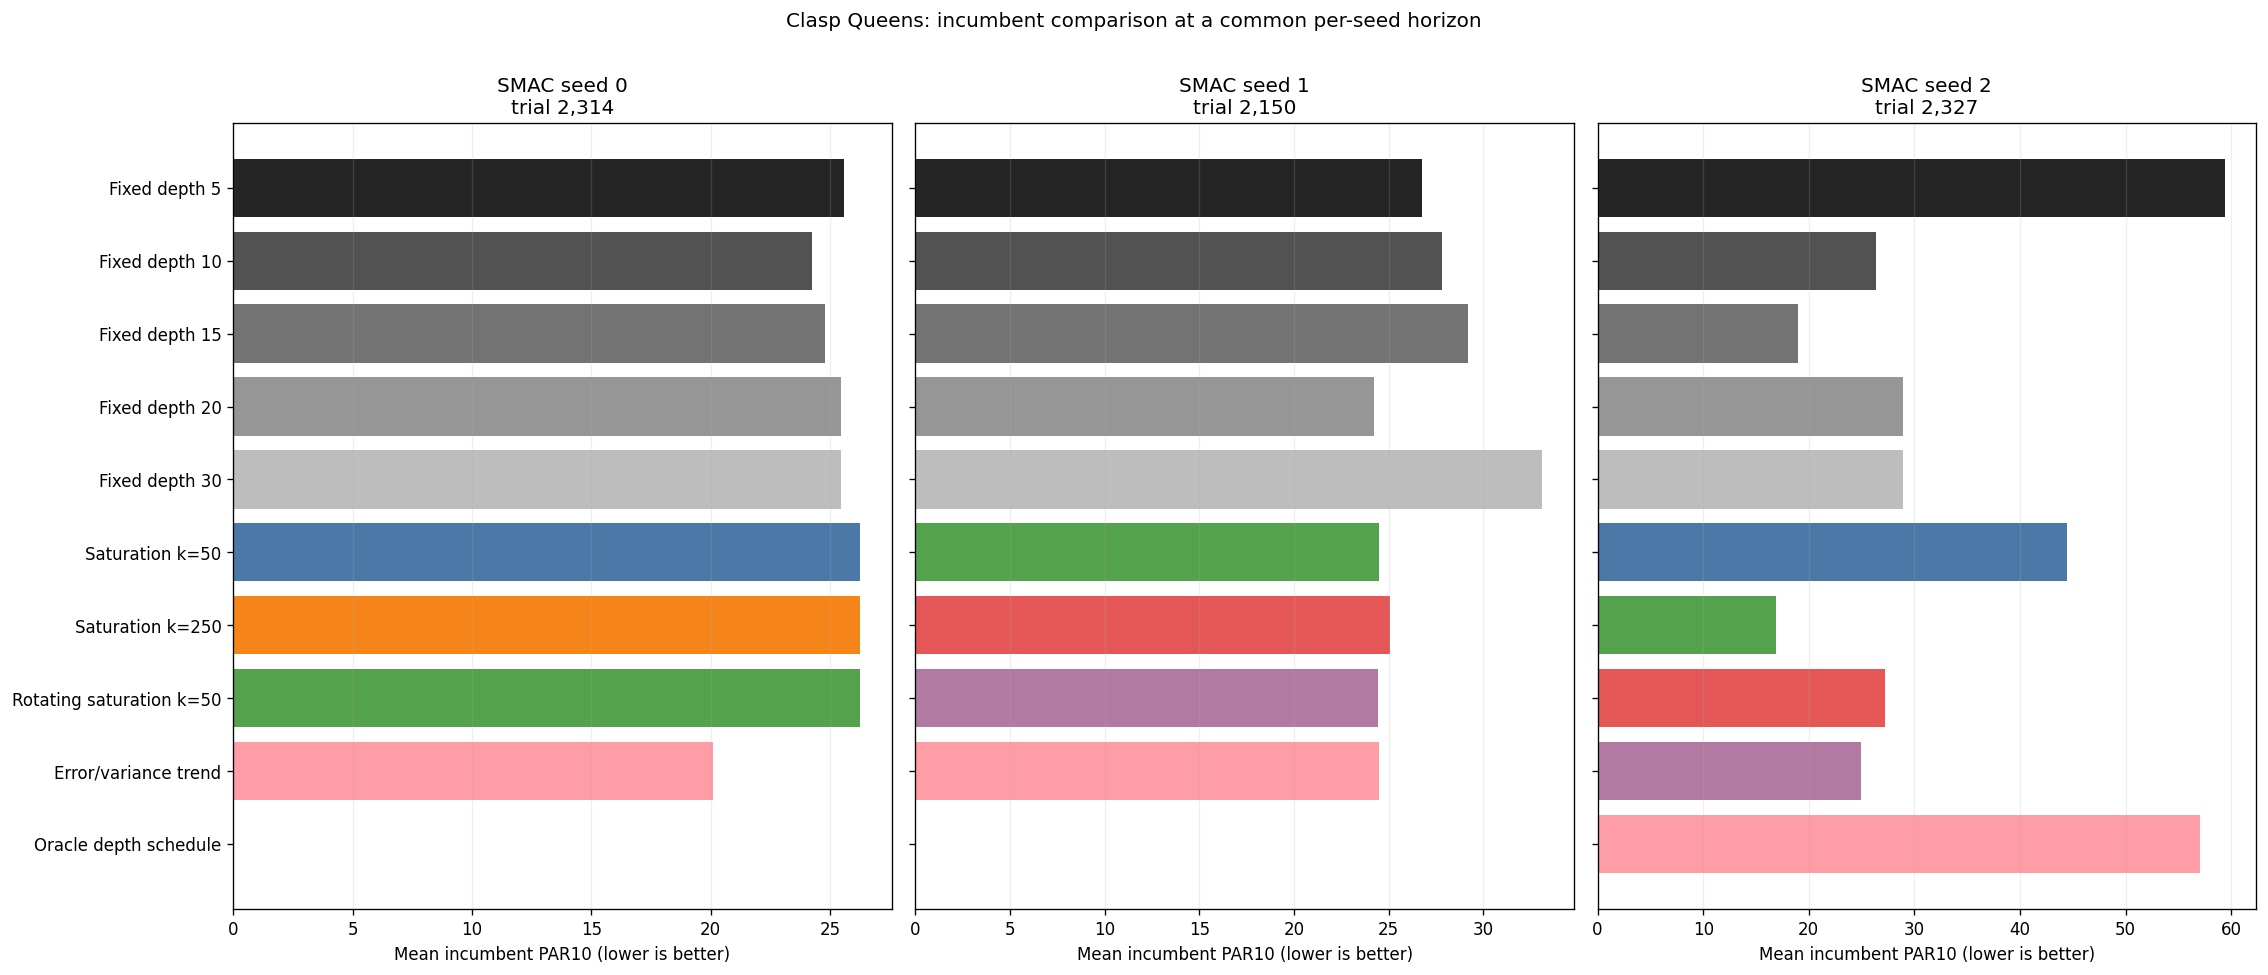

family  \
smac_seed common_trial method                                      
0         2314         Fixed depth 5                 fixed depth   
                       Fixed depth 10                fixed depth   
                       Fixed depth 15                fixed depth   
                       Fixed depth 20                fixed depth   
                       Fixed depth 30                fixed depth   
                       Saturation k=50           adaptive policy   
                       Saturation k=100          adaptive policy   
                       Saturation k=250          adaptive policy   
                       Oracle depth schedule     adaptive policy   
1         2150         Fixed depth 5                 fixed depth   
                       Fixed depth 10                fixed depth   
                       Fixed depth 15                fixed depth   
                       Fixed depth 20                fixed depth   
                       Fixed depth 30                fixed depth   
                       Saturation k=250          adaptive policy   
                       Rotating saturation k=50  adaptive policy   
                       Error/variance trend      adaptive policy   
                       Oracle depth schedule     adaptive policy   
2         2327         Fixed depth 5                 fixed depth   
                       Fixed depth 10                fixed depth   
                       Fixed depth 15                fixed depth   
                       Fixed depth 20                fixed depth   
                       Fixed depth 30                fixed depth   
                       Saturation k=50           adaptive policy   
                       Saturation k=250          adaptive policy   
                       Rotating saturation k=50  adaptive policy   
                       Error/variance trend      adaptive policy   
                       Oracle depth schedule     adaptive policy   

                                                 full_training_par10  
smac_seed common_trial method                                         
0         2314         Fixed depth 5                       25.601854  
                       Fixed depth 10                      24.230729  
                       Fixed depth 15                      24.790754  
                       Fixed depth 20                      25.461509  
                       Fixed depth 30                      25.461509  
                       Saturation k=50                     26.263510  
                       Saturation k=100                    26.263510  
                       Saturation k=250                    26.263510  
                       Oracle depth schedule               20.107653  
1         2150         Fixed depth 5                       26.793516  
                       Fixed depth 10                      27.839017  
                       Fixed depth 15                      29.200406  
                       Fixed depth 20                      24.231310  
                       Fixed depth 30                      33.131504  
                       Saturation k=250                    24.477254  
                       Rotating saturation k=50            25.061410  
                       Error/variance trend                24.458876  
                       Oracle depth schedule               24.477254  
2         2327         Fixed depth 5                       59.379225  
                       Fixed depth 10                      26.399246  
                       Fixed depth 15                      19.010385  
                       Fixed depth 20                      28.896640  
                       Fixed depth 30                      28.896640  
                       Saturation k=50                     44.404458  
                       Saturation k=250                    16.900913  
                       Rotating saturation k=50            27.238637  
                       Error/

In [5]:
plot_common_horizon_incumbents(comparison)
plt.show()
display(
    comparison.common_horizon.set_index(
        ['smac_seed', 'common_trial', 'method']
    )
)